In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lab 6 - Fisher's Linear Discriminant and Logistic Regression
- For equations, refer to Bishop's book, Section 4.1.4 and the slides

# Part I - Fisher's Linear Discriminant for Binary Classification (2 classes)

## Data Generation and Visualisation
- First we'll use scikit-learn to generate 2 blobs of data in 2D, using the [make_blobs()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) function.
- The data consists of 600 points divided into 2 classes, 0 and 1.

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(n_samples=600, centers=2, n_features=2, random_state=0)

Let's confirm the data has two classes

In [4]:
np.unique(y)

array([0, 1])

## Exercise 1
- Now create a scatter plot to visualise the generated data. 
- Make sure to paint each point based on the class they belong to, as shown in the Figure below.

<Axes: xlabel='dim_0', ylabel='dim_1'>

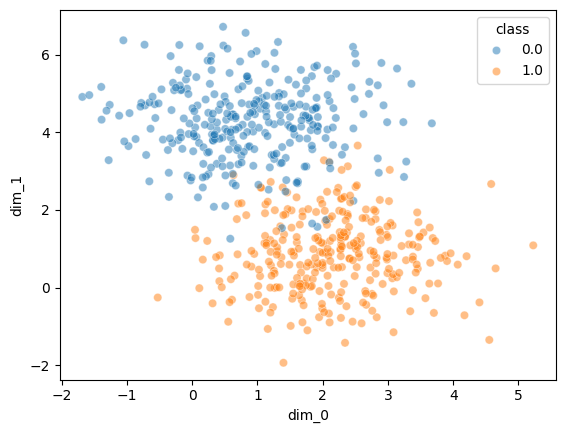

In [5]:
# your code goes here:
np_data = np.column_stack((X, y))
data = pd.DataFrame(np_data, columns=['dim_0', 'dim_1', 'class'])

sns.scatterplot(data=data, x='dim_0', y='dim_1', hue='class', alpha=0.5, palette='tab10')

## Exercise 2
* Now plot a histogram of the data projected on each of the 2 dimensions of $X$ ($0$ and $1$)

As an example, below is a figure that shows the projection on dimension $1$.

_Tips:_ 
* You can either use `histplot()` to generate the plot, in which case it might be easier to pack $X$ and $y$ into a pandas DataFrame.
* Alternatively, considering that you will generate this plot many times throughout this lab, you can write a function that takes the projected vector and the class labels.
* Use 30 bins to obtain a similar plot.

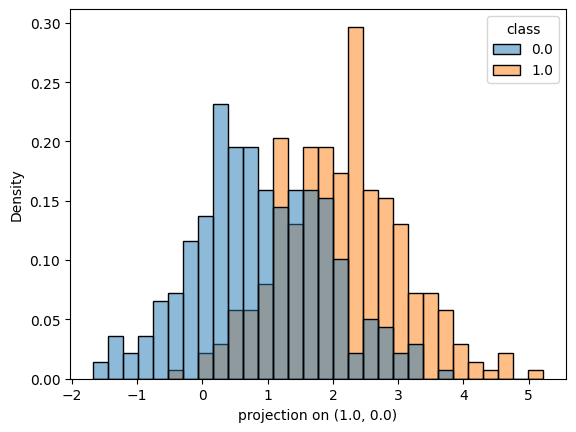

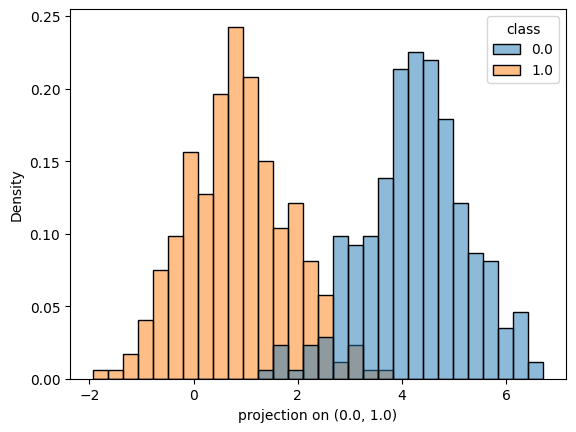

In [6]:
# your code goes here

def hist_proj(X, y, proj_vect):
    # proj de u em v = coef. u * unit. v
    # coef. u = norm. u * cos (u ~ v) 
    #       = norm. u * (u @ v) / (norm. u * norm. v)
    #       = (u @ v) / (norm. v)
    #       = u @ unit. v

    norm_proj = proj_vect / np.linalg.norm(proj_vect)
    proj_coef = X @ norm_proj
    proj_cat = np.column_stack((proj_coef, y))
    proj_cat_df = pd.DataFrame(proj_cat, columns=['value', 'class'])

    sns.histplot(data=proj_cat_df, x='value', hue='class', bins=30, stat='density', palette='tab10')

    plt.xlabel(f'projection on ({norm_proj[0]}, {norm_proj[1]})')
    plt.show()

hist_proj(X, y, np.array([1, 0]))
hist_proj(X, y, np.array([0, 1]))


## Exercise 3 - Implement Fisher's linear discriminant

* Use numpy to calculate $\vec{w}$.
* Plot the data (as you did in Exercise 1), and add a line on the direction of $\vec{w}$ (reference Figure below).
* Project the points onto the calculated vector, and plot the projection (as you did in Exercise 2) (reference Figure below).

In [7]:
# your code goes here:
def get_fisher_disc(X, y):
    np_data = np.column_stack((X, y))
    data = pd.DataFrame(np_data, columns=['dim_0', 'dim_1', 'class'])
    means = data.groupby('class').mean().values
    data['dim_0_norm'] = data['dim_0'] - data.groupby('class')['dim_0'].transform('mean')
    data['dim_1_norm'] = data['dim_1'] - data.groupby('class')['dim_1'].transform('mean')

    X_normalized = data[['dim_0_norm', 'dim_1_norm']].values
    S_W = X_normalized.T @ X_normalized 
    S_W = S_W / X.shape[0]
    # S_W = np.cov(data[['dim_0', 'dim_1']].values, rowvar=False)
    S_W_inv = np.linalg.inv(S_W)
    return S_W_inv @ (means[0] - means[1])

w = get_fisher_disc(X, y)

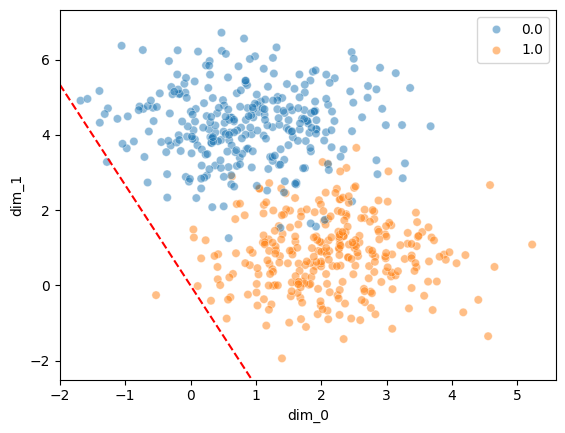

In [8]:
# your code goes here:
sns.scatterplot(data, x='dim_0', y='dim_1', hue='class', alpha=0.5)
pts = np.linspace(-2, 2, 20)
sns.lineplot(x=pts, y= (w[1] * pts) / w[0], linestyle='--', color='red')
plt.xlim(left=-2)
plt.ylim(bottom=-2.5)
plt.show()

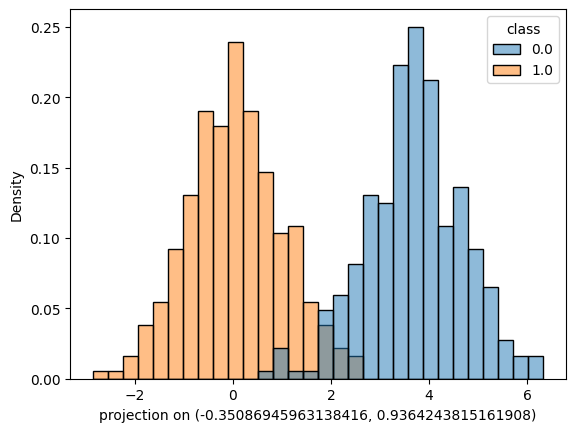

In [9]:
# your code goes here:
hist_proj(X, y, w)

## Exercise 4

* In this exercise you will use the `RidgeClassifier` from sklearn (as shown below) to obtain the class predictions from different types of projections:
    * component 0 of the data
    * component 1 of the data
    * the calculated vector $\vec{w}$
    
* Calculate the accuracy of these predictions using `accuracy_score` from sklearn.

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [11]:
# Follow this structure for each projection:
# r = RidgeClassifier()
# r.fit(projection, y)
# predicted_y = r.predict(projection)
# accuracy = accuracy_score(predicted_y, y)

In [12]:
# your code goes here:
dim0_proj = X @ np.array([1, 0])
dim0_proj = dim0_proj.reshape((-1, 1))
r_dim0 = RidgeClassifier()
r_dim0.fit(dim0_proj, y)
dim0_pred = r_dim0.predict(dim0_proj)
dim0_acc = accuracy_score(dim0_pred, y)

dim1_proj = X @ np.array([0, 1])
dim1_proj = dim1_proj.reshape((-1, 1))
r_dim1 = RidgeClassifier()
r_dim1.fit(dim1_proj, y)
dim1_pred = r_dim1.predict(dim1_proj)
dim1_acc = accuracy_score(dim1_pred, y)

fisher_proj = X @ w
fisher_proj = fisher_proj.reshape((-1, 1))
r_fisher = RidgeClassifier()
r_fisher.fit(fisher_proj, y)
fisher_pred = r_fisher.predict(fisher_proj)
fisher_acc = accuracy_score(fisher_pred, y)

print('projection: first dimension, accuracy = ', dim0_acc)
print('projection: second dimension, accuracy = ', dim1_acc)
print('projection: Fisher\'s linear discriminant, accuracy = ', fisher_acc)

projection: first dimension, accuracy =  0.7366666666666667
projection: second dimension, accuracy =  0.955
projection: Fisher's linear discriminant, accuracy =  0.965


# Part II - Generalised Linear Discriminant (multi-class)

**NOTE:** For this part you will be using a multi-class estimator from scikit-learn (read the [documentation](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)).

## Exercise 1 - Generate data

* Generate a 3 classes dataset in 2D, with the same rules as before (make 300 points per class)
* Plot the data and then similar histograms (on each dimension) as Part I Exercises 1 and 2.

[0 1 2]


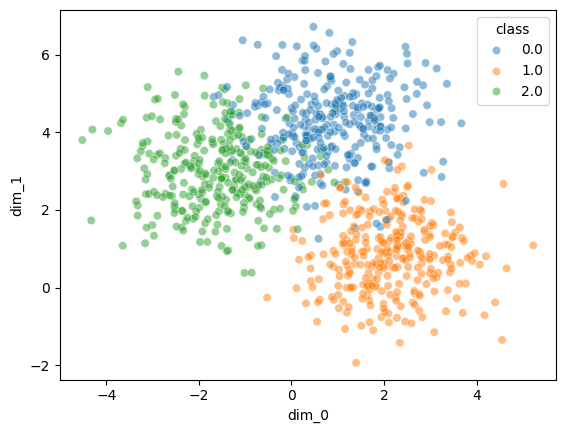

In [13]:
# your code goes here: 
X, y = make_blobs(n_samples=900, centers=3, n_features=2, random_state=0)
print(np.unique(y))

np_data = np.column_stack((X, y))
data = pd.DataFrame(np_data, columns=['dim_0', 'dim_1', 'class'])

sns.scatterplot(data=data, x='dim_0', y='dim_1', hue='class', alpha=0.5, palette='tab10')
plt.show()

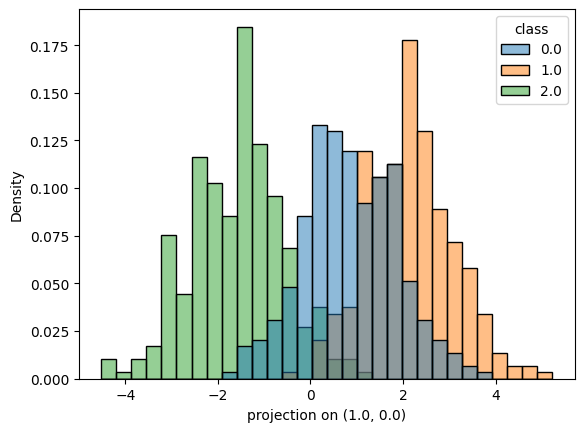

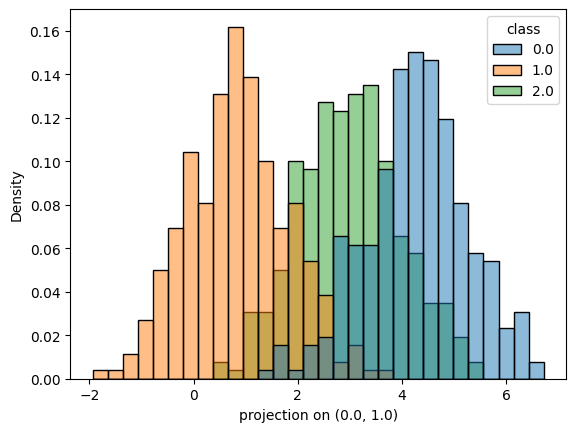

In [14]:
# your code goes here:
hist_proj(X, y, np.array([1, 0]))
hist_proj(X, y, np.array([0, 1]))

## Exercise 2 - Linear Discriminant Analysis

* Use sklearn's implementation of LDA to project the points in a single dimension and then plot the projected data

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Remember that since we want to project our data onto a vector, the parameter n_components of `LinearDiscriminantAnalysis` should be set to 1

<Axes: xlabel='proj', ylabel='Density'>

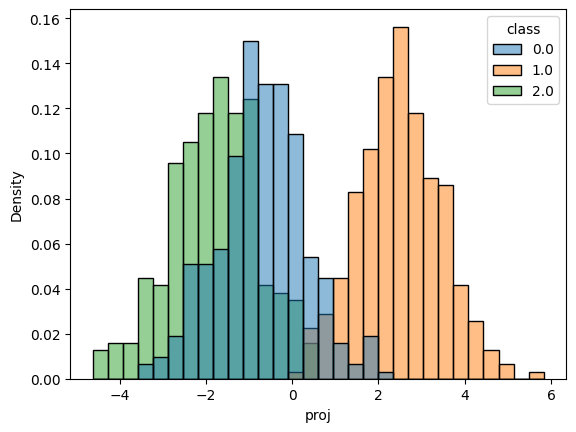

In [16]:
# your code goes here: 
clf = LinearDiscriminantAnalysis(n_components=1)
clf.fit(X, y)

X_transform = clf.transform(X)
np_data = np.column_stack((X_transform, y))
data = pd.DataFrame(np_data, columns=['proj', 'class'])
sns.histplot(data, x='proj', hue='class', bins=30, palette='tab10', stat='density')

## Exercise 3 - Calculate test set accuracy

* use the default parameters for the LDA classifier, and report the prediction accuracy on a train/test split of 70/30% (use `random_state=0`)
* report also the accuracy of the `RidgeClassfier` you used in Part I 

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# your code goes here:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)

lda_clf = LinearDiscriminantAnalysis(n_components=1)
lda_clf.fit(x_train, y_train)

r_clf = RidgeClassifier()
r_clf.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.For an illustration of the effect of alpha on the model coefficients, see:ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_class

In [19]:
lda_predict = lda_clf.predict(x_test)
r_predict = r_clf.predict(x_test)

lda_acc = accuracy_score(y_test, lda_predict)
r_acc = accuracy_score(y_test, r_predict)

print('Classifier: Linear Discriminant Analysis, accuracy: ', lda_acc)
print('Classifier: Ridge Classifier, accuracy: ', r_acc)

Classifier: Linear Discriminant Analysis, accuracy:  0.937037037037037
Classifier: Ridge Classifier, accuracy:  0.9259259259259259


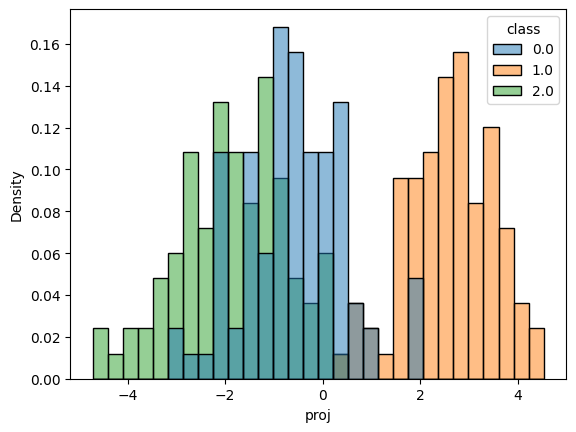

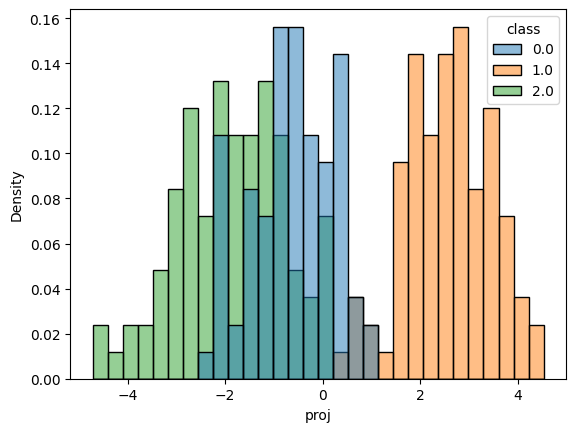

In [20]:
X_transform = lda_clf.transform(x_test)
np_data = np.column_stack((X_transform, y_test))
data = pd.DataFrame(np_data, columns=['proj', 'class'])
sns.histplot(data, x='proj', hue='class', bins=30, palette='tab10', stat='density')
plt.show()

np_data = np.column_stack((X_transform, lda_predict))
data = pd.DataFrame(np_data, columns=['proj', 'class'])
sns.histplot(data, x='proj', hue='class', bins=30, palette='tab10', stat='density')
plt.show()